# BirdCLEF+ 2026 — Exploratory Data Analysis

Competition: Multi-label species classification from passive acoustic monitoring soundscapes (Pantanal wetlands)  
Metric: Macro-ROC-AUC | Deadline: May 27, 2026  
**Kaggle constraint**: CPU only, runtime < 90 min

In [11]:
import os
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
# Local
DATA_DIR = Path('../data/raw')
# Kaggle: DATA_DIR = Path('/kaggle/input/competitions/birdclef-2026')

TRAIN_AUDIO_DIR = DATA_DIR / 'train_audio'
TRAIN_SND_DIR   = DATA_DIR / 'train_soundscapes'
TEST_SND_DIR    = DATA_DIR / 'test_soundscapes'

print('Data dir exists    :', DATA_DIR.exists())
print('train_audio files  :', sum(1 for _ in TRAIN_AUDIO_DIR.rglob('*.ogg')))
print('train_soundscapes  :', len(list(TRAIN_SND_DIR.glob('*.ogg'))))

Data dir exists    : True
train_audio files  : 35549
train_soundscapes  : 10658


## 1. Load Metadata

In [12]:
train_df   = pd.read_csv(DATA_DIR / 'train.csv')
tax_df     = pd.read_csv(DATA_DIR / 'taxonomy.csv')
snd_lbl_df = pd.read_csv(DATA_DIR / 'train_soundscapes_labels.csv')
sub_df     = pd.read_csv(DATA_DIR / 'sample_submission.csv')

# Parse list columns stored as strings
for col in ['secondary_labels', 'type']:
    train_df[col] = train_df[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else []
    )

train_df['primary_label'] = train_df['primary_label'].astype(str)
tax_df['primary_label']   = tax_df['primary_label'].astype(str)

print(f'train.csv        : {train_df.shape}')
print(f'taxonomy.csv     : {tax_df.shape}')
print(f'soundscape labels: {snd_lbl_df.shape}')
print(f'submission cols  : {sub_df.shape[1]-1} species')
train_df.head(3)

train.csv        : (35549, 15)
taxonomy.csv     : (234, 5)
soundscape labels: (1478, 4)
submission cols  : 234 species


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


## 2. Taxonomy — Species & Taxonomic Classes

In [13]:
print('=== Taxonomy Overview ===')
print(tax_df['class_name'].value_counts().to_string())
print(f'\nTotal species in taxonomy: {len(tax_df)}')

=== Taxonomy Overview ===
class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1

Total species in taxonomy: 234


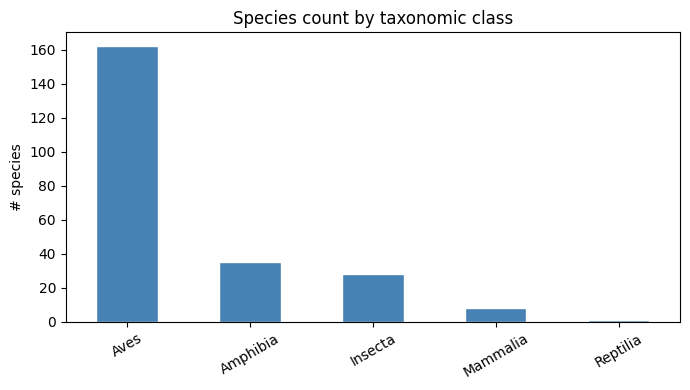

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
tax_df['class_name'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Species count by taxonomic class')
ax.set_xlabel('')
ax.set_ylabel('# species')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 3. Training Audio — Recordings per Species

In [15]:
counts = train_df['primary_label'].value_counts()

print(f'Total training recordings  : {len(train_df):,}')
print(f'Species with training audio: {counts.shape[0]}')
print(f'Min recordings per species : {counts.min()}')
print(f'Max recordings per species : {counts.max()}')
print(f'Median                     : {counts.median():.0f}')
print(f'Mean                       : {counts.mean():.1f}')

Total training recordings  : 35,549
Species with training audio: 206
Min recordings per species : 1
Max recordings per species : 499
Median                     : 125
Mean                       : 172.6


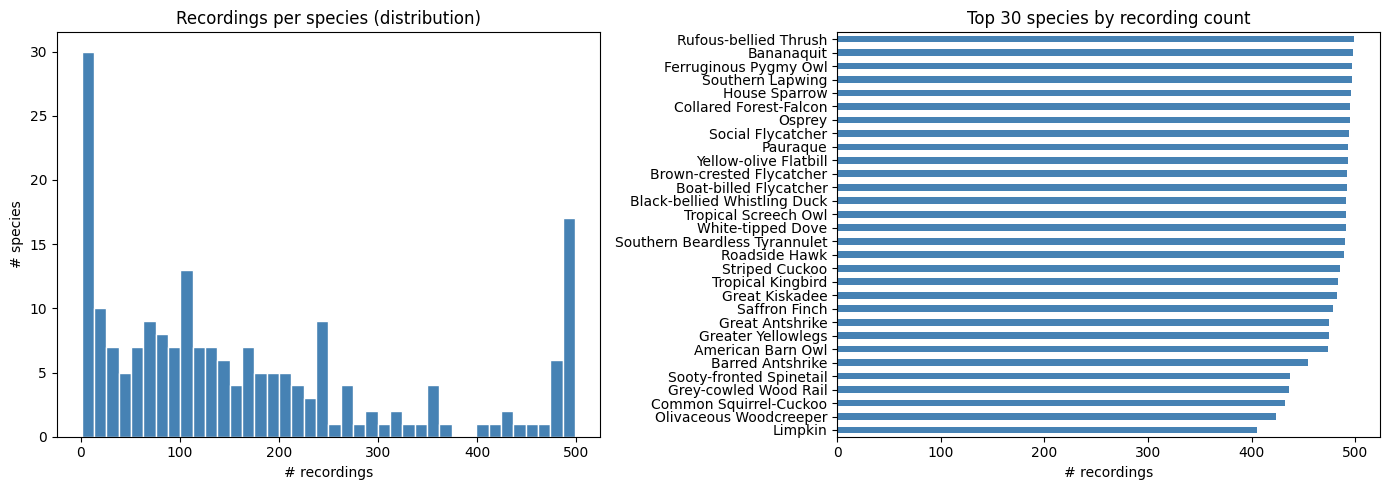

In [16]:
# Map label -> common name
label_to_name = dict(zip(tax_df['primary_label'], tax_df['common_name'].fillna(tax_df['primary_label'])))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution histogram
axes[0].hist(counts.values, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Recordings per species (distribution)')
axes[0].set_xlabel('# recordings')
axes[0].set_ylabel('# species')

# Top 30 species
top30 = counts.head(30).copy()
top30.index = [label_to_name.get(l, l) for l in top30.index]
top30.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('Top 30 species by recording count')
axes[1].set_xlabel('# recordings')

plt.tight_layout()
plt.show()

## 4. Recordings by Taxonomic Class

In [ ]:
class_counts = train_df['class_name'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
class_counts.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Training recordings by taxonomic class')
ax.set_ylabel('# recordings')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(class_counts)

## 5. Audio Quality — Ratings

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
train_df['rating'].hist(bins=20, ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Recording quality ratings')
ax.set_xlabel('Rating (0–5)')
ax.set_ylabel('# recordings')
plt.tight_layout()
plt.show()

print(train_df['rating'].describe())
zero_rated = (train_df['rating'] == 0).sum()
print(f'\nZero-rated recordings: {zero_rated:,} ({zero_rated/len(train_df)*100:.1f}%)')

## 6. Geographic Distribution

In [ ]:
geo = train_df.dropna(subset=['latitude', 'longitude'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(geo['longitude'], geo['latitude'], s=4, alpha=0.3, c='steelblue')
ax.set_title(f'Recording locations ({len(geo):,} with coordinates)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## 7. Data Collections & Secondary Labels

In [ ]:
print('Recordings by collection source:')
print(train_df['collection'].value_counts())

has_secondary = train_df['secondary_labels'].apply(len) > 0
print(f'\nRecordings with secondary labels: {has_secondary.sum():,} ({has_secondary.mean()*100:.1f}%)')
print('\nSecondary label count distribution:')
print(train_df['secondary_labels'].apply(len).value_counts().sort_index().head(10))

## 8. Soundscape Labels — Co-occurrence

In [ ]:
print('=== Soundscape Labels ===')
print(snd_lbl_df.head())
print(f'\nTotal 5-second windows: {len(snd_lbl_df):,}')
print(f'Unique soundscapes    : {snd_lbl_df["filename"].nunique()}')

In [ ]:
snd_lbl_df['species_list'] = snd_lbl_df['primary_label'].apply(
    lambda x: [s.strip() for s in str(x).split(';')] if pd.notna(x) else []
)
snd_lbl_df['n_species'] = snd_lbl_df['species_list'].apply(len)

fig, ax = plt.subplots(figsize=(7, 4))
snd_lbl_df['n_species'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Species co-occurrence per 5s window (train soundscapes)')
ax.set_xlabel('# species simultaneously active')
ax.set_ylabel('# windows')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print(f'Max co-occurring species : {snd_lbl_df["n_species"].max()}')
print(f'Mean species per window  : {snd_lbl_df["n_species"].mean():.2f}')

## 9. Submission Format

In [ ]:
species_cols = [c for c in sub_df.columns if c != 'row_id']
print(f'Submission species columns: {len(species_cols)}')
print(f'\nRow ID format example: {sub_df["row_id"].iloc[0]}')
print('  → <soundscape_filename>_<end_second>')
print(f'\nFirst 5 row IDs:')
print(sub_df['row_id'].head(5).to_string(index=False))

## 10. Audio Visualization — Single Recording

In [ ]:
SR         = 32000
N_MELS     = 128
HOP_LENGTH = 320    # ~10ms per frame at 32kHz
N_FFT      = 1024
FMIN       = 20
FMAX       = 16000

# Pick a high-rated recording
good = train_df[train_df['rating'] >= 4.0]
sample = good.sample(1, random_state=42).iloc[0]
audio_path = TRAIN_AUDIO_DIR / sample['filename']
print(f'Species : {sample["common_name"]} ({sample["class_name"]})')
print(f'Rating  : {sample["rating"]}')
print(f'File    : {audio_path}')

wav, _ = librosa.load(audio_path, sr=SR, mono=True)
wav = wav[:SR * 5]   # first 5 seconds

mel = librosa.feature.melspectrogram(
    y=wav, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
    hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX
)
mel_db = librosa.power_to_db(mel, ref=np.max)

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

times = np.linspace(0, len(wav) / SR, len(wav))
axes[0].plot(times, wav, color='steelblue', lw=0.5)
axes[0].set_title(f'Waveform — {sample["common_name"]} ({sample["scientific_name"]})')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

img = librosa.display.specshow(
    mel_db, sr=SR, hop_length=HOP_LENGTH,
    x_axis='time', y_axis='mel',
    fmin=FMIN, fmax=FMAX, ax=axes[1], cmap='magma'
)
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Mel-Spectrogram (128 mels, 32kHz, 5s crop)')

plt.tight_layout()
plt.show()

## 11. Soundscape Audio Visualization

In [ ]:
soundscapes = list(TRAIN_SND_DIR.glob('*.ogg'))
print(f'Training soundscapes: {len(soundscapes)}')

if soundscapes:
    snd_path = soundscapes[0]
    snd_wav, _ = librosa.load(snd_path, sr=SR, mono=True, duration=60)
    print(f'File    : {snd_path.name}')
    print(f'Loaded  : {len(snd_wav)/SR:.1f}s (first 60s)')

    mel_snd = librosa.feature.melspectrogram(
        y=snd_wav, sr=SR, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX
    )
    mel_snd_db = librosa.power_to_db(mel_snd, ref=np.max)

    fig, ax = plt.subplots(figsize=(14, 4))
    img = librosa.display.specshow(
        mel_snd_db, sr=SR, hop_length=HOP_LENGTH,
        x_axis='time', y_axis='mel',
        fmin=FMIN, fmax=FMAX, ax=ax, cmap='magma'
    )
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title(f'Soundscape (first 60s) — {snd_path.name}')
    for t in range(5, 65, 5):
        ax.axvline(x=t, color='cyan', lw=0.5, linestyle='--', alpha=0.5)
    ax.axvline(x=5, color='cyan', lw=1, linestyle='--', alpha=0.8, label='5s inference windows')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

## 12. Key Findings Summary

| Item | Value |
|---|---|
| Total training recordings | run cell 3 |
| Taxonomic classes | Aves, Insecta, Reptilia, Amphibia |
| Target species (submission) | ~234 |
| Soundscape window size | 5 seconds |
| Audio sample rate | 32,000 Hz |
| Mel bins used | 128 |

### Modelling implications
- **Multi-label**: BCEWithLogitsLoss — predict all species per 5s window simultaneously  
- **Class imbalance**: consider weighted sampling or focal loss — distribution is long-tailed  
- **Zero-rated audio**: filter or down-weight low-quality recordings during training  
- **CPU-only inference (< 90 min)**: EfficientNet-B0 or MobileNetV3, no heavy TTA  
- **Soundscape inference**: sliding 5s windows, aggregate by species over full recording